# Cellohood Data Preparation & Training Tutorial

In this notebook we will go through an example training / post-processing of Cellohood model.


## Data Preparation

At the base of the Cellohood analysis is the single cell marker expression matrix with cell positions. In order to proceed one needs to fill out the following variables:

- `DATA_PATH` - path to a cell data,
- `MARKER_COL_NAMES` - a collection of marker columns,
- `DISTANCE_THRESHOLD` - cells will be clustered into bags of roughly this diamater. This distance should reflect the distance at which you expect the cell interactions to be valid,
- `POSITION_COLS` - a list / tuple with columns of cell positions. Cellohood accepts any dimensionality of the input,
- `IMAGE_COL_NAME` - a column with information about from which image / slide comes from,
- `SAMPLE_COL_NAME` - as some patients / mice / etc. might have multiple slides - this additional column represents to which columns does a given cell belongs.

In [23]:
import pandas
import joblib

from ccs import ccs
import cellohood


DATA_PATH = '/raid/immucan/immuw/image_analysis/analysis/UW/packages/IMMUW/scripts/mexpose_skin_normalised_phenotypes.csv'
data_df = pandas.read_csv(DATA_PATH)


MARKER_COL_NAMES = [
    'Anti-Alpha-Smooth Muscle Actin', 'Anti-WGA',
       'Anti-Human CD163 (EDHu-1)', 'Anti-Pan-Keratin',
       'Anti-Vimentin (RV202)', 'Anti-Human CD63 (H5C6)',
       'Anti-Human/Mouse CD34 (EP373Y)', 'Anti-CD45', 'Anti-CD44', 'Anti-CD4',
       'Anti-E-Cadherin', 'Anti-CD68', 'Anti-CD11c (EP1347Y)',
       'Anti-Human CD8a (D8A8Y)', 'Anti-CD206/MMR (5C11)',
       'Anti-Human/Mouse S100 beta (EP1576Y)', 'Anti-pH2AX', 'Anti-CD45RA',
       'Anti-Ki-67', 'Anti-Collagen Type I', 'Anti-CD3', 'Anti-Caspase 3',
       'Anti-Human CD45RO', 'Anti-HLA-DR', 'Anti-pHistone H3', 'Sodium',
       'Magnesium', 'Phosphorus', 'Calcium', 'Iron', 'Copper', 'Zinc',
       'Cobalt'
]

DISTANCE_THRESHOLD = 50.
POS_COL_NAMES = ['x', 'y']
IMAGE_ID_COLUMN = 'image'
SAMPLE_COL_NAME = 'image'

TRAIN_MODEL = True
SAVING_PATH = 'CelloTutorialModel'

TRAIN_LATENT_DIRECTIONS = True
LD_SAVING_PATH = 'ld.pickle'

FINAL_DF_SAVING_PATH = 'final_cello_df.csv'

First step in the data preprocessing is to transform a cell df to a `BagCelloDf` object. This methods runs the hierarchical clustering cells into bags using `DISTANCE_THRESHOLD` as a threshold. It later assigns each cell its bag id (by default `cellohood_neighborhood_cluster`). The object contains:
- `cell_df` - a transformed cell data frame with bag assignment,
- `image_id_column`- check the description of `IMAGE_ID_COLUMN` above,
- `pos_col_names` - check the description of `POS_COL_NAMES` above,
- `distance_threshold` - check the description of `DISTANCE_THRESHOLD` above,
- `marker_col_names` - check the `MARKER_COL_NAMES` above,
- `cellohood_neighborhood_cluster_colname` - in this column an id of a cell's bag is stored (by default `cellohood_neighborhood_cluster`.
        

In [2]:
bag_cello_df = cellohood.transform_df_to_bag_cello_df(
    df_=data_df,
    image_id_column=IMAGE_ID_COLUMN,
    pos_col_names=POS_COL_NAMES,
    distance_threshold=DISTANCE_THRESHOLD,
    marker_col_names=MARKER_COL_NAMES,
)

If one wants to apply a popular `arcsinh(x / 5.)` transform - there is a function for that:

In [3]:
_ = cellohood.apply_arcsinh_to_bag_cello_df(bag_cello_df, inplace=True)

Now - it's time for train / test split of the `bag_cello_df`. The code below produces two `BagCelloDf`s - train and test ones. In case, when one wants to train Cellohood without test set (treating it as a sort of cellular neighborhood PCA) - the `split_percentage` should be set to `1.`. In this case, the `test_bag_cello_df` is set to `None`.

**NOTE:** this tests are splitted by samples - so that separate samples are in the train and test sets.

In [4]:
train_bag_cello_df, test_bag_cello_df = cellohood.split_bag_cello_df_by(
    bag_cello_df,
    by=SAMPLE_COL_NAME,
    split_percentage=1.,
)

It is good to standardize data first. The code below uses `standardize_bag_cello_df` function that accepts as its input:
- `train_bag_cello_df`, `test_bag_cello_df` - train and test `BagCelloDfs`,
- `marker_scaler` (default `"standard"`) - a marker scaler. For `"standard"` value it uses Standard Scaler, for `"min-max"` it uses MinMaxScaler, `None` uses Identity Scaler. One may also pass any object with `transform` method that will transform cell marker expressions,
- `pca_dimensions` (default `0`) - number of PCA dimensions used for the analysis. If it is set to `0` no PCA transformation is applied,
- `inplace` (default `False`) - if standarization should be performed in place,
- `fit_marker_scaler` - in case when one passes it's own scaler, this indicates if it will be fitted or not. If set to `True` a passed scaler object should have a `fit` method.

It fits `marker_scaler` on the `train_bag_cello_df`, and applies it to the `test_bag_cello_df` (it automatically covers if `test_bag_cello_df` is `None`). It outputs a `StandardizedBagCelloDfs` `namedtuple` containing:

- `train_cello_df`, `test_cello_df`, `BagCelloDf` objects with scaled `cell_df`s,
- `marker_scaler` - scaler instance,
- `marker_col_names` - names of marker columns,
- `output_size` - size of the single cell vectors (`pca_dimensions` if PCA was applied, `len(marker_col_names)` otherwise).

In [5]:
standardized_cello_dfs = cellohood.standardize_bag_cello_df(
    train_bag_cello_df=train_bag_cello_df, 
    test_bag_cello_df=test_bag_cello_df,
    marker_col_names=MARKER_COL_NAMES,
)

Now, it's time to train `Cellohood`. `cellohood.train` method accepts as its input:


- `standardized_cello_dfs` - a `StandardizedBagCelloDfs` object that `Cellohood` will be trained on,
- `batch_size: int = 512` - a batch size used in the training,
- `epoch_nb: int = 1000` a number of epochs,
- `optimizer_lr: float = 0.0001` - learning rate used by `ADAM` optimizer,
- `optimizer_clipnorm: float = 1.0` - a clip norm for optimizer,
- `use_cuda: bool = True` - if model should be trained on `GPU`,
- `layer_size: int = 128` - a size of the transformer layer sizes for both encoder and decoder,
- `intermediate_layer_size: int = 256` - a size of a hidden transformer later,
- `latent_size: int = 64` - size of a `Cellohood` latent,
- `tensorboard_path: Optional[str] = None` - a log path to optional TensorBoard callback.

This method outputs `CellohoodModel` `namedtuple` with the following fields:
- `model` - an instance of a `Keras` `Cellohood` model,
- `history` - `Keras` training history,
- `marker_scaler` - scaler used in training,
- `marker_col_names` - names of marker used,
- `output_size` output size of a model,
- `max_neighborhood_size` - a maximal bag size used by the model.

In [6]:
if TRAIN_MODEL:
    cello_train_result = cellohood.train(
        standardized_cello_dfs=standardized_cello_dfs,
        epoch_nb=1000,
        use_cuda=False,
    )

2025-03-02 14:12:49.076058: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-03-02 14:12:49.076110: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: rudy
2025-03-02 14:12:49.076118: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: rudy
2025-03-02 14:12:49.076389: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 535.183.1
2025-03-02 14:12:49.076416: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 535.183.1
2025-03-02 14:12:49.076422: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 535.183.1


Train on 1486 samples


2025-03-02 14:12:54.885010: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/1000
1486/1486 - 7s - loss: 0.8103 - ent: 2.3906 - 7s/epoch - 4ms/sample
Epoch 2/1000
1486/1486 - 3s - loss: 0.7335 - ent: 2.3355 - 3s/epoch - 2ms/sample
Epoch 3/1000
1486/1486 - 3s - loss: 0.6794 - ent: 2.4137 - 3s/epoch - 2ms/sample
Epoch 4/1000
1486/1486 - 3s - loss: 0.6397 - ent: 2.4145 - 3s/epoch - 2ms/sample
Epoch 5/1000
1486/1486 - 3s - loss: 0.6059 - ent: 2.4225 - 3s/epoch - 2ms/sample
Epoch 6/1000
1486/1486 - 3s - loss: 0.5794 - ent: 2.4191 - 3s/epoch - 2ms/sample
Epoch 7/1000
1486/1486 - 3s - loss: 0.5581 - ent: 2.4214 - 3s/epoch - 2ms/sample
Epoch 8/1000
1486/1486 - 3s - loss: 0.5410 - ent: 2.3635 - 3s/epoch - 2ms/sample
Epoch 9/1000
1486/1486 - 3s - loss: 0.5258 - ent: 2.4012 - 3s/epoch - 2ms/sample
Epoch 10/1000
1486/1486 - 3s - loss: 0.5141 - ent: 2.4128 - 3s/epoch - 2ms/sample
Epoch 11/1000
1486/1486 - 3s - loss: 0.5037 - ent: 2.3507 - 3s/epoch - 2ms/sample
Epoch 12/1000
1486/1486 - 3s - loss: 0.4961 - ent: 2.3514 - 3s/epoch - 2ms/sample
Epoch 13/1000
1486/1486 -

1486/1486 - 3s - loss: 0.2918 - ent: 2.2166 - 3s/epoch - 2ms/sample
Epoch 102/1000
1486/1486 - 3s - loss: 0.2912 - ent: 2.2165 - 3s/epoch - 2ms/sample
Epoch 103/1000
1486/1486 - 3s - loss: 0.2914 - ent: 2.2172 - 3s/epoch - 2ms/sample
Epoch 104/1000
1486/1486 - 3s - loss: 0.2906 - ent: 2.2171 - 3s/epoch - 2ms/sample
Epoch 105/1000
1486/1486 - 3s - loss: 0.2903 - ent: 2.2176 - 3s/epoch - 2ms/sample
Epoch 106/1000
1486/1486 - 3s - loss: 0.2898 - ent: 2.2176 - 3s/epoch - 2ms/sample
Epoch 107/1000
1486/1486 - 3s - loss: 0.2895 - ent: 2.2182 - 3s/epoch - 2ms/sample
Epoch 108/1000
1486/1486 - 3s - loss: 0.2893 - ent: 2.2169 - 3s/epoch - 2ms/sample
Epoch 109/1000
1486/1486 - 3s - loss: 0.2888 - ent: 2.2193 - 3s/epoch - 2ms/sample
Epoch 110/1000
1486/1486 - 3s - loss: 0.2886 - ent: 2.2182 - 3s/epoch - 2ms/sample
Epoch 111/1000
1486/1486 - 3s - loss: 0.2885 - ent: 2.2185 - 3s/epoch - 2ms/sample
Epoch 112/1000
1486/1486 - 3s - loss: 0.2882 - ent: 2.2188 - 3s/epoch - 2ms/sample
Epoch 113/1000
1486

...

Epoch 596/1000
1486/1486 - 3s - loss: 0.1482 - ent: 2.1585 - 3s/epoch - 2ms/sample
Epoch 597/1000
1486/1486 - 2s - loss: 0.1476 - ent: 2.1611 - 2s/epoch - 2ms/sample
Epoch 598/1000
1486/1486 - 3s - loss: 0.1476 - ent: 2.1617 - 3s/epoch - 2ms/sample
Epoch 599/1000
1486/1486 - 3s - loss: 0.1474 - ent: 2.1611 - 3s/epoch - 2ms/sample
Epoch 600/1000
1486/1486 - 3s - loss: 0.1477 - ent: 2.1623 - 3s/epoch - 2ms/sample
Epoch 601/1000
1486/1486 - 3s - loss: 0.1472 - ent: 2.1623 - 3s/epoch - 2ms/sample
Epoch 602/1000
1486/1486 - 3s - loss: 0.1469 - ent: 2.1587 - 3s/epoch - 2ms/sample
Epoch 603/1000
1486/1486 - 3s - loss: 0.1472 - ent: 2.1605 - 3s/epoch - 2ms/sample
Epoch 604/1000
1486/1486 - 3s - loss: 0.1469 - ent: 2.1618 - 3s/epoch - 2ms/sample
Epoch 605/1000
1486/1486 - 3s - loss: 0.1468 - ent: 2.1616 - 3s/epoch - 2ms/sample
Epoch 606/1000
1486/1486 - 3s - loss: 0.1465 - ent: 2.1615 - 3s/epoch - 2ms/sample
Epoch 607/1000
1486/1486 - 3s - loss: 0.1462 - ent: 2.1580 - 3s/epoch - 2ms/sample
Epoc

Epoch 695/1000
1486/1486 - 3s - loss: 0.1395 - ent: 2.1569 - 3s/epoch - 2ms/sample
Epoch 696/1000
1486/1486 - 3s - loss: 0.1394 - ent: 2.1567 - 3s/epoch - 2ms/sample
Epoch 697/1000
1486/1486 - 3s - loss: 0.1401 - ent: 2.1579 - 3s/epoch - 2ms/sample
Epoch 698/1000
1486/1486 - 3s - loss: 0.1400 - ent: 2.1562 - 3s/epoch - 2ms/sample
Epoch 699/1000
1486/1486 - 3s - loss: 0.1395 - ent: 2.1545 - 3s/epoch - 2ms/sample
Epoch 700/1000
1486/1486 - 3s - loss: 0.1390 - ent: 2.1577 - 3s/epoch - 2ms/sample
Epoch 701/1000
1486/1486 - 3s - loss: 0.1392 - ent: 2.1575 - 3s/epoch - 2ms/sample
Epoch 702/1000
1486/1486 - 3s - loss: 0.1393 - ent: 2.1544 - 3s/epoch - 2ms/sample
Epoch 703/1000
1486/1486 - 3s - loss: 0.1397 - ent: 2.1572 - 3s/epoch - 2ms/sample
Epoch 704/1000
1486/1486 - 3s - loss: 0.1397 - ent: 2.1535 - 3s/epoch - 2ms/sample
Epoch 705/1000
1486/1486 - 3s - loss: 0.1396 - ent: 2.1592 - 3s/epoch - 2ms/sample
Epoch 706/1000
1486/1486 - 3s - loss: 0.1392 - ent: 2.1553 - 3s/epoch - 2ms/sample
Epoc

Epoch 794/1000
1486/1486 - 3s - loss: 0.1327 - ent: 2.1494 - 3s/epoch - 2ms/sample
Epoch 795/1000
1486/1486 - 3s - loss: 0.1329 - ent: 2.1521 - 3s/epoch - 2ms/sample
Epoch 796/1000
1486/1486 - 3s - loss: 0.1328 - ent: 2.1507 - 3s/epoch - 2ms/sample
Epoch 797/1000
1486/1486 - 3s - loss: 0.1327 - ent: 2.1519 - 3s/epoch - 2ms/sample
Epoch 798/1000
1486/1486 - 3s - loss: 0.1327 - ent: 2.1508 - 3s/epoch - 2ms/sample
Epoch 799/1000
1486/1486 - 3s - loss: 0.1327 - ent: 2.1508 - 3s/epoch - 2ms/sample
Epoch 800/1000
1486/1486 - 3s - loss: 0.1334 - ent: 2.1542 - 3s/epoch - 2ms/sample
Epoch 801/1000
1486/1486 - 3s - loss: 0.1333 - ent: 2.1463 - 3s/epoch - 2ms/sample
Epoch 802/1000
1486/1486 - 3s - loss: 0.1337 - ent: 2.1523 - 3s/epoch - 2ms/sample
Epoch 803/1000
1486/1486 - 3s - loss: 0.1337 - ent: 2.1515 - 3s/epoch - 2ms/sample
Epoch 804/1000
1486/1486 - 3s - loss: 0.1336 - ent: 2.1504 - 3s/epoch - 2ms/sample
Epoch 805/1000
1486/1486 - 3s - loss: 0.1334 - ent: 2.1496 - 3s/epoch - 2ms/sample
Epoc

Epoch 893/1000
1486/1486 - 3s - loss: 0.1279 - ent: 2.1472 - 3s/epoch - 2ms/sample
Epoch 894/1000
1486/1486 - 3s - loss: 0.1279 - ent: 2.1456 - 3s/epoch - 2ms/sample
Epoch 895/1000
1486/1486 - 3s - loss: 0.1281 - ent: 2.1447 - 3s/epoch - 2ms/sample
Epoch 896/1000
1486/1486 - 3s - loss: 0.1285 - ent: 2.1478 - 3s/epoch - 2ms/sample
Epoch 897/1000
1486/1486 - 3s - loss: 0.1278 - ent: 2.1460 - 3s/epoch - 2ms/sample
Epoch 898/1000
1486/1486 - 3s - loss: 0.1284 - ent: 2.1463 - 3s/epoch - 2ms/sample
Epoch 899/1000
1486/1486 - 3s - loss: 0.1281 - ent: 2.1455 - 3s/epoch - 2ms/sample
Epoch 900/1000
1486/1486 - 3s - loss: 0.1280 - ent: 2.1469 - 3s/epoch - 2ms/sample
Epoch 901/1000
1486/1486 - 2s - loss: 0.1277 - ent: 2.1479 - 2s/epoch - 2ms/sample
Epoch 902/1000
1486/1486 - 3s - loss: 0.1278 - ent: 2.1456 - 3s/epoch - 2ms/sample
Epoch 903/1000
1486/1486 - 3s - loss: 0.1278 - ent: 2.1463 - 3s/epoch - 2ms/sample
Epoch 904/1000
1486/1486 - 3s - loss: 0.1277 - ent: 2.1480 - 3s/epoch - 2ms/sample
Epoc

Epoch 992/1000
1486/1486 - 3s - loss: 0.1230 - ent: 2.1430 - 3s/epoch - 2ms/sample
Epoch 993/1000
1486/1486 - 3s - loss: 0.1232 - ent: 2.1442 - 3s/epoch - 2ms/sample
Epoch 994/1000
1486/1486 - 3s - loss: 0.1231 - ent: 2.1442 - 3s/epoch - 2ms/sample
Epoch 995/1000
1486/1486 - 3s - loss: 0.1228 - ent: 2.1420 - 3s/epoch - 2ms/sample
Epoch 996/1000
1486/1486 - 2s - loss: 0.1232 - ent: 2.1418 - 2s/epoch - 2ms/sample
Epoch 997/1000
1486/1486 - 3s - loss: 0.1234 - ent: 2.1436 - 3s/epoch - 2ms/sample
Epoch 998/1000
1486/1486 - 3s - loss: 0.1233 - ent: 2.1450 - 3s/epoch - 2ms/sample
Epoch 999/1000
1486/1486 - 3s - loss: 0.1232 - ent: 2.1420 - 3s/epoch - 2ms/sample
Epoch 1000/1000
1486/1486 - 3s - loss: 0.1228 - ent: 2.1422 - 3s/epoch - 2ms/sample


once we have a model, we can serialize its result using `cellohood.save_cello_train_result` function. Deserialization is performed by `cellohood.load_cello_train_result`:

In [7]:
if TRAIN_MODEL:
    cellohood.save_cello_train_result(cello_train_result, SAVING_PATH)
else:
    cello_train_result = cellohood.load_cello_train_result(SAVING_PATH)

Now - we are ready to obtain the model results. In order to run prediction of a `Cellohood` model on the `BagCelloDf`, one may use `cellohood.run_prediction_on_cell_df`. Note however, that the data that this model is used on should not be scaled, as the scaling of the data is performed using scaler used during the train. That's why in the code below we use non-scaled `BagCelloDf`:

In [8]:
cello_prediction = cellohood.run_prediction_on_cello_df(
    cello_train_result,
    bag_cello_df,
)

/raid/immucan/immuw/cellohood_venv/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


It outputs `CelloPrediction` `namedtuple` with fields:
- `cell_predictions` - with dataframe of Cellohood cell representations, together with image and position information,
- `bag_predictions` - with dataframe of Cellohood bag representations, together with image and position information,
- `cello_columns` - with set of column names storing the Cellohood representations,
- `cellohood_neighborhood_cluster_colname` - column with the cellohood bag index,
- `image_id_column` - column with information about the image id,
- `pos_col_names` - positional columns.

As we use a set of disjoint bags in the training, we decided to compensate for the effect that disjoint tissue cutting might have on results - by spatially smoothing the results. Here - the value for each cell is spatially smoothed across all cells within a `distance_threshold`. In our experiments we set it to `DISTANCE_THRESHOLD` that is the same threshold as we used in original tissue cutting. Note - that as this process might be time / memory consuming we implemented multiprocess setup which uses `cache_path` folder to cache multiprocess result. Be default, for safety reasons, we implemented the assertion that this folder does not exist, so make sure that you use unused folder.

In [11]:
smoothed_df_result = cellohood.smooth_cellohood_prediction(
    cello_prediction,
    distance_threshold=DISTANCE_THRESHOLD,
    cache_path='new_cache',
)

After smoothin it's worth to delete `cache`:

In [10]:
!rm -r new_cache/

Now, let's prepare latent directions. Latent directions is a method that provides opportunity to set the resolution of the analysis of the latent space. It works in a following way:

1. For a set of `explained_variance_levels` it computes the PCA of the provided `columns` in `df`,
2. It clusters it separately using [`cellohood_cluster_selection`](https://github.com/marmarmarmar/cellohood-cluster-selection) algorithm.

A function `get_latent_direction` accepts:
- `df` - Dataframe with latent representations,
- `columns` - column names of latent representations to use,
- `explained_variance_levels` - levels of variance used for the analysis,
- `min_nb_of_clusters` - minimal number of clusters checked in the cluster selection algorithm,
- `max_nb_of_clusters` - maximal number of clusters checked in the cluster selection algorithm,
- `clusters_step` - the difference between consecutive number of clusters candidates checked in the cluster selection algorithm,
- `nb_of_tries_per_cluster_nb` - how many alternative runs are used for a given cluster number,
- `take_every_example_for_training` - a subsampling ratio for examples for cluster selection.

It returns a `LatentDirectionResult` namedtuple with the following fields:
- `explained_variance_level_to_n_components` - dictionary that stores the information about how many dimensions were elected for a given variance level,
- `explained_variance_level_to_ccs_result` - dictionary that stores `cellohood_cluster_selection` results for a given variance level,
- `pca_sm_data` - array with a `PCA` transformed data,
- `pca` - a fitted `sklearn` `PCA` transformer.

In [24]:
if TRAIN_LATENT_DIRECTIONS:
    latent_direction_result = cellohood.get_latent_directions(
        df=smoothed_df_result.cell_predictions,
        columns=smoothed_df_result.cello_columns,
        explained_variance_levels=(0.5, 0.75, 1.),
        min_nb_of_clusters=5,
        max_nb_of_clusters=30,
        nb_of_tries_per_cluster_nb=5,
        take_every_example_for_training=1,
        clusters_step=1,
    )
    joblib.dump(latent_direction_result, LD_SAVING_PATH)
else:
    latent_direction_result = joblib.load(LD_SAVING_PATH)

Once the `latent_directions` are fitted we can summarize their results using `cellohood.summarize_latent_direction_result` function:

In [25]:
cellohood.summarize_latent_direction_result(latent_direction_result)

Latent Direction Summary:
Variance: 0.5 (dim=1), selected clusters = [10, 13, 18, 21, 24].
Variance: 0.75 (dim=3), selected clusters = [9, 21].
Variance: 1.0 (dim=63), selected clusters = [10, 13, 20].


Or even plot cluster selection result for a specific variance level:

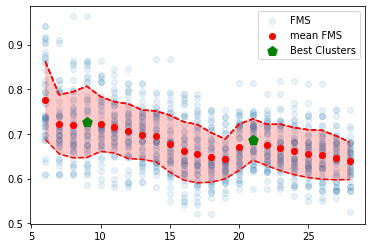

In [26]:
ccs.plot_ccs_result(latent_direction_result.explained_variance_level_to_ccs_result[0.75])

Now we are ready to select cluster / variance ratio for a further analysis. In this tutorial we will select only the smallest number of selected clusters:

In [27]:
variance_to_nb_of_clusters = {
    0.5: [10],
    0.75: [9],
    1.0: [10],
}

Now we can extend `cellohood` `cell_df` with appropriate predictions:

In [28]:
for variance, nbs_of_clusters in variance_to_nb_of_clusters.items():
    for nb_of_clusters in nbs_of_clusters:
        bag_cello_df.cell_df[f'{variance}:{nb_of_clusters}'] = cellohood.get_latent_directions_predictions(
            latent_direction_result=latent_direction_result,
            explained_variance=variance,
            selected_number_of_clusters=nb_of_clusters,
        )

Now we can save the final results into the appropriate `df`:

In [29]:
bag_cello_df.cell_df.to_csv(FINAL_DF_SAVING_PATH)